# 문제 2 — 회전 행렬 구현과 합성 순서 검증

축별 회전 행렬 `rot_x`, `rot_y`, `rot_z` 를 직접 구현하고,
회전이 갖는 성질들을 행렬과 그림 양쪽으로 확인합니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 2-1 | 축별 회전 행렬을 만들고 `rot_z(90도)` 가 (1,0,0) 을 (0,1,0) 으로 보내는지 확인 | `rot_x`, `rot_y`, `rot_z` |
| 2-2 | 세 축 회전을 **Matplotlib 3D 로 그려** 회전축 성분이 보존됨을 눈으로 확인 | — |
| 2-3 | **합성 순서가 다르면 결과가 달라짐**을 행렬과 **나란히 그린 3D 그림**으로 비교 | — |
| 2-4 | 세 회전 행렬의 행렬식과 반사 행렬 `diag(1,1,-1)` 의 행렬식을 비교하고 **왜 1 이어야 하는지** 설명 | (문제 1 의 `det`) |
| 2-5 | 문제 1 의 `skew` 로 **로드리게스 공식**을 구현하고 `rot_z` 와 일치하는지 검증 | `rodrigues` |

> 각도는 **라디안**으로 받습니다. 도 단위는 `np.deg2rad` 로 바꿔 넣으세요.
> 순서 의존성 비교 그림은 **반드시 포함**되어야 합니다.

In [236]:
import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import rodrigues, rot_x, rot_y, rot_z
from src.vectors import det, skew          # 문제 1 에서 만든 함수를 재사용

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 한글 라벨이 깨지지 않도록 폰트 지정 (Windows 기준, 없으면 기본 폰트로 fallback)
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# --- 그림 헬퍼 (그대로 쓰면 됩니다) -----------------------------------------

def draw_frame(ax, R=np.eye(3), origin=(0, 0, 0), scale=1.0, alpha=1.0, labels=None):
    """회전 행렬 R 의 세 열을 x(빨강)·y(초록)·z(파랑) 축으로 그린다."""
    origin = np.asarray(origin, dtype=float)
    colors = ["r", "g", "b"]
    names = labels if labels else ["x", "y", "z"]
    for i in range(3):
        v = R[:, i] * scale
        ax.quiver(*origin, *v, color=colors[i], alpha=alpha, arrow_length_ratio=0.15)
        ax.text(*(origin + v * 1.12), names[i], color=colors[i], fontsize=9)


def setup_axes(ax, title, lim=1.3):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("준비 완료")

준비 완료


## 2-1. 축별 회전 행렬과 `rot_z(90도)` 검증

오른손 좌표계에서 각 축 회전 행렬은 다음과 같습니다.

$$R_x(\theta)=\begin{bmatrix}1&0&0\0&\cos\theta&-\sin\theta\0&\sin\theta&\cos\theta\end{bmatrix},\quad
R_y(\theta)=\begin{bmatrix}\cos\theta&0&\sin\theta\0&1&0\-\sin\theta&0&\cos\theta\end{bmatrix},\quad
R_z(\theta)=\begin{bmatrix}\cos\theta&-\sin\theta&0\\sin\theta&\cos\theta&0\0&0&1\end{bmatrix}$$

$R_y$ 만 부호 배치가 뒤집혀 보입니다. 오른손 규칙에서 y축 회전이 어느 축에서
어느 축으로 도는지 생각해 보면 이유를 설명할 수 있습니다.

**할 일** — 세 함수를 구현하고, $R_z(90^\circ)$ 를 $(1,0,0)$ 에 적용한 결과를 확인하세요.

In [237]:
# TODO: rot_z(90도) 행렬과 (1,0,0) 을 회전시킨 결과를 출력하세요.
R_z90 = rot_z(np.pi/2)
# TODO: rot_x(90도), rot_y(90도) 도 함께 출력해 형태를 확인하세요.
R_x90 = rot_x(np.pi/2)
R_y90 = rot_y(np.pi/2)

print("rot_x(90) = ", R_x90, "rot_y(90) = ", R_y90, "rot_z(90) = ", R_z90)

rot_x(90) =  [[ 1.  0.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]] rot_y(90) =  [[ 0.  0.  1.]
 [ 0.  1.  0.]
 [-1.  0.  0.]] rot_z(90) =  [[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]


In [238]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - rot_z(90도) @ (1,0,0) == (0,1,0)
v_x = np.array([1.0, 0.0, 0.0])
v_y = np.array([0.0, 1.0, 0.0])
v_z = np.array([0.0, 0.0, 1.0])
I = np.eye(3)
theta = rng.uniform(0, 2*np.pi)

p_ztransform = R_z90 @ v_x
check("rot_z(90도) @ (1,0,0) == (0,1,0)", np.allclose(p_ztransform, v_y, atol=1e-15))
#   - rot_x(90도) @ (0,1,0) == ?      (직접 예상하고 확인)
p_xtransform = R_x90 @ v_y
print("rot_x(90도) @ (0,1,0) = ", p_xtransform)
#   - rot_y(90도) @ (0,0,1) == ?
p_ytransform = R_y90 @ v_z
print("rot_y(90도) @ (0,0,1) = ", p_ytransform)
#   - 0도 회전은 단위행렬인가
check("0도 회전은 단위행렬인가", np.allclose(rot_z(0), I))
#   - R(theta) @ R(-theta) == I 인가
check("R(theta) @ R(-theta) == I 인가", np.allclose(rot_z(theta) @ rot_z((-1)*theta), I))
#   - 회전이 길이를 보존하는가
check("회전이 길이를 보존하는가", np.isclose(det(R_x90), 1.0))

[PASS] rot_z(90도) @ (1,0,0) == (0,1,0)
rot_x(90도) @ (0,1,0) =  [0. 0. 1.]
rot_y(90도) @ (0,0,1) =  [1. 0. 0.]
[PASS] 0도 회전은 단위행렬인가
[PASS] R(theta) @ R(-theta) == I 인가
[PASS] 회전이 길이를 보존하는가


True

## 2-2. 축별 회전 3D 시각화 — 회전축 성분은 보존된다

임의의 점 하나를 각 축 기준으로 0 ~ 360도 돌리면 궤적이 어떤 모양이 되는지,
그리고 **어떤 성분이 변하지 않는지** 그림으로 확인합니다.

**할 일**

- 점 $p_0=(1, 0.6, 0.8)$ 을 각 축으로 0~2π 돌린 궤적을 계산하세요.
- 3분할 3D 그림(`fig.add_subplot(1, 3, k+1, projection="3d")`)으로 그리고,
  위에서 준 `draw_frame` / `setup_axes` 로 좌표축과 축 범위를 정리하세요.
- 각 그림에 회전축을 점선으로 함께 그리면 보존 관계가 한눈에 들어옵니다.
- **보존되는 성분의 변화폭**(max - min)을 수치로 계산해 제목이나 출력에 남기세요.
  이 값이 검증 셀의 근거가 됩니다.

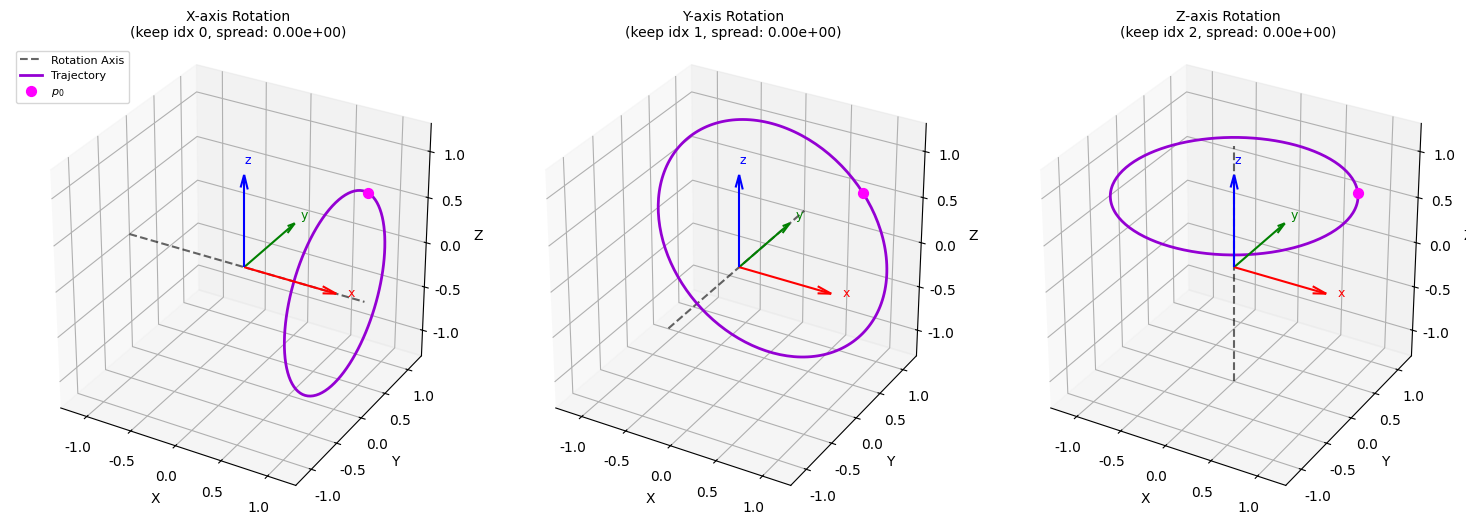

In [239]:
p0 = np.array([1.0, 0.6, 0.8])
angles = np.linspace(0, 2 * np.pi, 200)

info = []     # (이름, 보존 성분의 변화폭) 을 담아 두면 검증 셀에서 쓰기 좋습니다

# TODO: 세 축에 대해 궤적을 만들고 3D 로 그리세요.
#   for k, (name, maker, axis_vec, keep) in enumerate([...]):
#       traj = ...
#       spread = ...
#       info.append((name, spread))
fig = plt.figure(figsize=(15, 5))

axes_config = [
    ("X-axis", rot_x, np.array([1.0, 0.0, 0.0]), 0),
    ("Y-axis", rot_y, np.array([0.0, 1.0, 0.0]), 1),
    ("Z-axis", rot_z, np.array([0.0, 0.0, 1.0]), 2)
]

for k, (name, maker, axis_vec, keep) in enumerate(axes_config):
    traj = np.array([maker(theta) @ p0 for theta in angles])

    keep_components = traj[:, keep]
    spread = float(np.max(keep_components) - np.min(keep_components))
    info.append((name, spread))

    ax = fig.add_subplot(1,3,k+1,projection="3d")
    setup_axes(ax, title=f"{name} Rotation\n(keep idx {keep}, spread: {spread:.2e})", lim=1.3)

    draw_frame(ax, R=np.eye(3), origin=(0, 0, 0), scale=1.0)
    
    axis_line = np.outer(np.linspace(-1.3, 1.3, 10), axis_vec)
    ax.plot(axis_line[:, 0], axis_line[:, 1], axis_line[:, 2], "k--", alpha=0.6, label="Rotation Axis")
    
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color="darkviolet", lw=2, label="Trajectory")
    ax.scatter(p0[0], p0[1], p0[2], color="magenta", s=50, zorder=5, label="$p_0$")
    
    if k == 0:
        ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


In [240]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 세 회전 각각에서 보존 성분의 변화폭이 기계정밀도 수준인가
all_spreads_zero = all(np.isclose(spread, 0.0, atol=1e-15) for name, spread in info)
check("세 회전 각각에서 보존 성분의 변화폭이 기계정밀도 수준인가", all_spreads_zero)
#   - 궤적 위 모든 점이 원점에서 등거리인가 (회전은 길이 보존)
is_isometric = True

for k, (name, maker, axis_vec, keep) in enumerate(axes_config):
    for theta in angles:
        R = maker(theta)
        if not (np.isclose(det(R), 1.0, atol=1e-15) and np.allclose(R.T @ R, I, atol=1e-15)):
            is_isometric = False
            break

check("궤적 위 모든 점이 원점에서 등거리인가 (회전은 길이 보존)", is_isometric)

[PASS] 세 회전 각각에서 보존 성분의 변화폭이 기계정밀도 수준인가
[PASS] 궤적 위 모든 점이 원점에서 등거리인가 (회전은 길이 보존)


True

## 2-3. 합성 순서가 다르면 결과가 다르다

행렬 곱은 교환법칙이 성립하지 않습니다: $R_y R_z \neq R_z R_y$.

표기 약속: $R_y R_z \mathbf{p}$ 는 "**$R_z$ 를 먼저**, 그다음 $R_y$" 라는 뜻입니다
(오른쪽 것이 먼저 적용됩니다).

**할 일**

- y축 90도와 z축 90도를 두 순서로 합성해 결과 행렬 A, B 를 만들고 차이를 출력하세요.
- 같은 초기 자세(단위행렬)가 두 순서로 어떻게 다르게 끝나는지
  **초기 / 순서① / 순서②** 3분할 3D 그림으로 나란히 그리세요.
- 왜 물리적으로 당연한 결과인지 아래에 적으세요.

### 순서가 결과를 바꾸는 이유

- `기준이 되는 축이 회전과 함께 움직이거나 고정되기 때문, 행렬의 곱셈에 교환법칙이 성립하지 않기 때문`

In [241]:
ang = np.deg2rad(90.0)
# TODO: A = rot_y(ang) @ rot_z(ang), B = rot_z(ang) @ rot_y(ang) 를 만들고
A = rot_y(ang) @ rot_z(ang)
B = rot_z(ang) @ rot_y(ang)
#       두 행렬과 차이(최대 절댓값)를 출력하세요.
matrix_diff =  np.max(np.abs(A-B))
print("두 행렬 A : ", A, "B : ", B, "차이(최대 절댓값) : ", matrix_diff)
# TODO: (1,0,0) 이 두 순서에서 각각 어디로 가는지도 출력하세요.
p_A = A @ v_x
p_B = B @ v_x
print(p_A, p_B)

두 행렬 A :  [[ 0. -0.  1.]
 [ 1.  0.  0.]
 [-0.  1.  0.]] B :  [[ 0. -1.  0.]
 [ 0.  0.  1.]
 [-1.  0.  0.]] 차이(최대 절댓값) :  1.0
[ 0.  1. -0.] [ 0.  0. -1.]


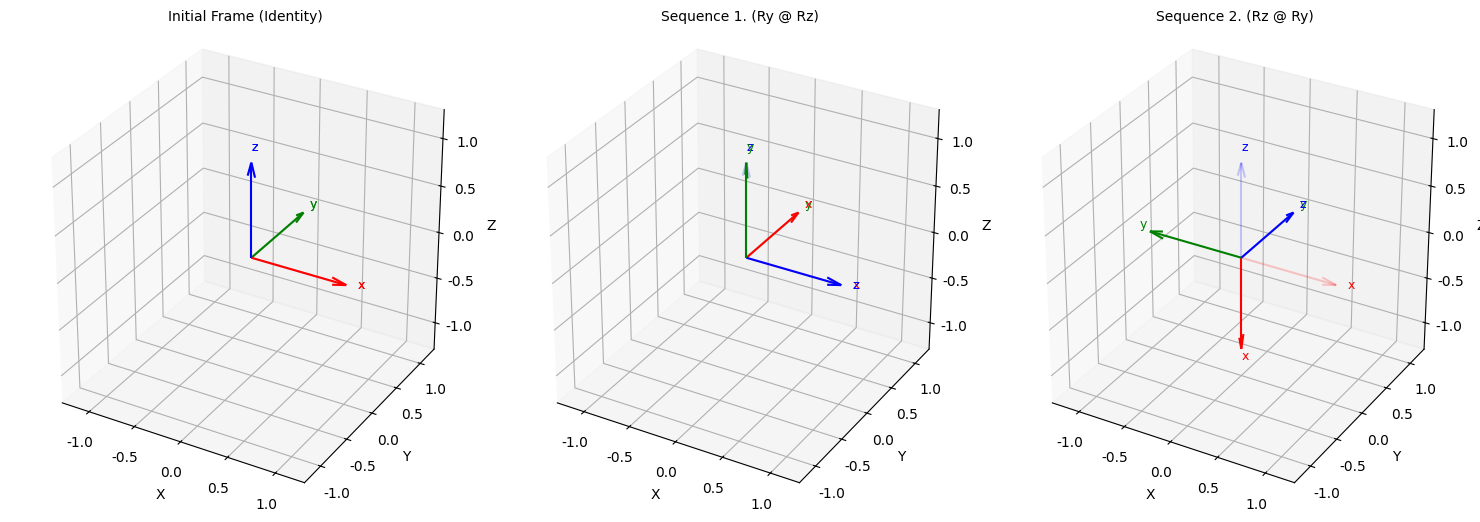

In [242]:
# TODO: 3분할 3D 그림 (초기 자세 / 순서① / 순서②) 을 그리세요.
fig = plt.figure(figsize=(15, 5))
titles = ["Initial Frame (Identity)", "Sequence 1. (Ry @ Rz)", "Sequence 2. (Rz @ Ry)"]
frames = [I, A, B]

for k, (title, R_curr) in enumerate(zip(titles, frames)):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    setup_axes(ax, title, lim=1.3)
#       draw_frame(ax, np.eye(3), alpha=0.2) 로 기준 좌표계를 흐리게 깔면 비교가 쉽습니다.
    draw_frame(ax, R=I, origin=(0, 0, 0), scale=1.0, alpha=0.2)
    draw_frame(ax, R=R_curr, origin=(0, 0, 0), scale=1.0, alpha=1.0)

plt.tight_layout()
plt.show()

In [243]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 두 합성 결과 행렬이 다른가
check("두 합성 결과 행렬이 다른가", not np.allclose(A,B))
#   - 같은 축끼리는 순서를 바꿔도 같은가 (교환 가능)
check("같은 축끼리는 순서를 바꿔도 같은가 (교환 가능)", np.allclose(rot_z(ang) @ rot_z(ang), rot_z(ang) @ rot_z(ang)))
#   - 각도가 0 이면 순서가 무의미한가
A_zero = rot_y(0.0) @ rot_z(0.0)
B_zero = rot_z(0.0) @ rot_y(0.0)
check("각도가 0 이면 순서가 무의미한가", np.allclose(A_zero, B_zero))
#   - 두 결과 모두 회전행렬인가 (det = 1)
is_rot_matrix = np.isclose(det(A), 1.0) and np.isclose(det(B), 1.0)
check("두 결과 모두 회전행렬인가 (det = 1)", is_rot_matrix)
#   - A 와 B 가 (1,0,0) 을 서로 다른 곳으로 보내는가
check("A 와 B 가 (1,0,0) 을 서로 다른 곳으로 보내는가", not np.allclose(p_A, p_B))

[PASS] 두 합성 결과 행렬이 다른가
[PASS] 같은 축끼리는 순서를 바꿔도 같은가 (교환 가능)
[PASS] 각도가 0 이면 순서가 무의미한가
[PASS] 두 결과 모두 회전행렬인가 (det = 1)
[PASS] A 와 B 가 (1,0,0) 을 서로 다른 곳으로 보내는가


True

## 2-4. 행렬식이 1 이어야 하는 이유 — 회전 vs 반사

직교행렬($R^{\mathsf{T}}R=I$)의 행렬식은 $\pm 1$ 뿐입니다.
$\det(R^{\mathsf{T}}R)=\det(R)^2=\det(I)=1$ 이기 때문입니다.

그렇다면 $\det = -1$ 인 직교행렬은 무엇일까요?
대각성분이 $(1,1,-1)$ 인 행렬을 놓고 다음을 직접 확인해 보세요.

- 직교성($S^{\mathsf{T}}S=I$)은 만족하는가
- 행렬식은 얼마인가
- $\mathbf{x}' \times \mathbf{y}' = \mathbf{z}'$ (오른손 규칙)이 유지되는가

세 질문의 답을 모으면 "왜 직교만으로는 부족하고 $\det=+1$ 까지 요구하는가" 가 나옵니다.
로봇 자세에 $\det=-1$ 행렬이 들어가면 실제로 무슨 일이 벌어질지도 함께 적으세요.

### 행렬식이 1 이어야 하는 이유

- 회전 행렬 세 개의 행렬식: `1.0` / 반사 행렬의 행렬식: `-1.0`
- 차이의 의미: `부호가 바뀌며 반사되며 오른손 규칙도 깨지고 좌표계도 바뀜`
- 로봇에서의 영향: `뒤집힌 기하학적 형태로, 외적 연산의 부호가 전부 뒤집혀 로봇이 오작동하거나 궤적이 완전히 꼬이게 됨`

In [244]:
S = np.diag([1.0, 1.0, -1.0])     # z 를 뒤집는 반사 행렬

matrices = [
    ("rot_x(90)", R_x90),
    ("rot_y(90)", R_y90),
    ("rot_z(90)", R_z90),
    ("Reflect S", S)
]

print(f"{'Matrix':<12} | {'Determinant':<11} | {'Orthogonal Error':<16} | {'Right-Hand Rule (x` × y` == z`)':<25}")
# TODO: 회전 행렬 3개와 반사 행렬 S 에 대해
#       det(직접 구현), 직교 오차 |M.T @ M - I| 를 표로 출력하세요.
# TODO: 각 행렬에 대해 x' x y' == z' 인지도 함께 출력하세요.
for name, M in matrices:
    d_M = det(M)

    ortho_error = np.max(np.abs(M.T @ M-I))
    x_prime = M[:,0]
    y_prime = M[:,1]
    z_prime = M[:,2]

    cross_skew = skew(x_prime) @ y_prime
    is_rhr = np.allclose(cross_skew, z_prime, atol=1e-15)

    print(f"{name:<12} | {d_M:<11.1f} | {ortho_error:<16.2e} | {str(is_rhr):<25}")


Matrix       | Determinant | Orthogonal Error | Right-Hand Rule (x` × y` == z`)
rot_x(90)    | 1.0         | 0.00e+00         | True                     
rot_y(90)    | 1.0         | 0.00e+00         | True                     
rot_z(90)    | 1.0         | 0.00e+00         | True                     
Reflect S    | -1.0        | 0.00e+00         | False                    


In [245]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 세 회전 행렬의 행렬식이 모두 1 인가
rot_det = np.isclose(det(R_x90), 1.0) and np.isclose(det(R_y90), 1.0) and np.isclose(det(R_z90), 1.0)
check("세 회전 행렬의 행렬식이 모두 1 인가", rot_det)
#   - 반사 행렬의 행렬식은 -1 인가
check("반사 행렬의 행렬식은 -1 인가", np.isclose(det(S), -1.0))
#   - 반사 행렬도 직교이긴 한가
check("반사 행렬도 직교이긴 한가", np.allclose(S.T @ S, I,  atol=1e-15))
#   - 회전은 오른손 규칙을 보존하는가 / 반사는 깨뜨리는가
r_rhr = np.allclose(skew(R_z90[:,0]) @ R_z90[:, 1], R_z90[:, 2])
s_rhr = np.allclose(skew(S[:,0]) @ S[:,1], S[:,2])
check("회전은 오른손 규칙을 보존하는가 / 반사는 깨뜨리는가", r_rhr and (not s_rhr))
#   - 무작위 회전 100개의 det 가 모두 1 인가
random_rot = True
for _ in range(100):
    rng_rx = rot_x(rng.uniform(0, 2*np.pi))
    rng_ry = rot_y(rng.uniform(0, 2*np.pi))
    rng_rz = rot_z(rng.uniform(0, 2*np.pi))
    R_rand = rng_rx @ rng_ry @ rng_rz

    if not np.isclose(det(R_rand), 1.0, atol=1e-12):
        random_rot = False
        break

check("무작위 회전 100개의 det 가 모두 1 인가", random_rot)

[PASS] 세 회전 행렬의 행렬식이 모두 1 인가
[PASS] 반사 행렬의 행렬식은 -1 인가
[PASS] 반사 행렬도 직교이긴 한가
[PASS] 회전은 오른손 규칙을 보존하는가 / 반사는 깨뜨리는가
[PASS] 무작위 회전 100개의 det 가 모두 1 인가


True

## 2-5. 로드리게스 공식 — `skew` 로 임의 축 회전

단위 축 $\mathbf{k}$ 를 중심으로 $\theta$ 만큼 도는 회전은

$$R = I + \sin\theta\,[\mathbf{k}]_\times + (1-\cos\theta)\,[\mathbf{k}]_\times^2$$

로 쓸 수 있습니다. 문제 1 에서 만든 `skew` 가 그대로 들어갑니다.
축을 $\mathbf{k}=(0,0,1)$ 로 두면 `rot_z` 와 정확히 같아야 합니다.

**할 일** — `src/rotation.py` 의 `rodrigues` 를 구현하고,
z축·임의 축 두 경우를 확인하세요. 축이 회전 후에도 그대로인지도 봅니다.

In [246]:
theta = np.deg2rad(37.0)

# TODO: rodrigues([0,0,1], theta) 와 rot_z(theta) 를 비교 출력하세요.
R_rod_z = rodrigues(v_z, theta)
R_rot_z = rot_z(theta)

print(R_rod_z, R_rot_z, np.max(np.abs(R_rod_z - R_rot_z)))
# TODO: 임의 축 k = (1, 2, -0.5) 로도 만들어 보고, R @ k 가 k 그대로인지 확인하세요.
k = np.array([1.0, 2.0, -0.5])
# TODO: skew 로 공식을 손으로 조립한 결과와 rodrigues 결과가 같은지 확인하세요.
R_k = rodrigues(k, theta)

k_norm = k / np.sqrt(np.sum(k**2))
R_k_norm = R_k / k_norm

print(k_norm, R_k_norm, np.max(np.abs(R_k_norm - k_norm)))

k_skew = skew(k_norm)
R_hand = I + np.sin(theta) * k_skew + (1.0 - np.cos(theta)) * (k_skew @ k_skew)

print(np.max(np.abs(R_hand - R-k)))

[[ 0.798636 -0.601815  0.      ]
 [ 0.601815  0.798636  0.      ]
 [ 0.        0.        1.      ]] [[ 0.798636 -0.601815  0.      ]
 [ 0.601815  0.798636  0.      ]
 [ 0.        0.        1.      ]] 0.0
[ 0.436436  0.872872 -0.218218] [[ 1.917787  0.238336 -2.319377]
 [-0.125142  1.090717  1.379395]
 [-1.247571  0.256966 -3.703749]] 3.4855311214013183
2.047943926179216


In [247]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - rodrigues(z축) == rot_z, rodrigues(x축) == rot_x, rodrigues(y축) == rot_y
check(" rodrigues(x축) == rot_x", np.allclose(rodrigues(v_x, theta), rot_x(theta), atol=1e-15))
check(" rodrigues(y축) == rot_y", np.allclose(rodrigues(v_y, theta), rot_y(theta), atol=1e-15))
check(" rodrigues(z축) == rot_z", np.allclose(rodrigues(v_z, theta), rot_z(theta), atol=1e-15))
#   - 임의 축 결과가 회전행렬인가 (det = 1, 직교)
is_rot = np.isclose(det(R_k), 1.0, atol=1e-14) and np.allclose(R_k.T @ R_k, I, atol=1e-15)
check("임의 축 결과가 회전행렬인가 (det = 1, 직교)", is_rot)
#   - 회전축은 변하지 않는가 (R k == k)
check("회전축은 변하지 않는가 (R k == k)", np.allclose(R_k @ k_norm, k_norm, atol=1e-15))
#   - 정규화되지 않은 축을 줘도 같은 결과인가
R_unnorm = rodrigues(k, theta)
R_normed = rodrigues(k_norm, theta)
check("정규화되지 않은 축을 줘도 같은 결과인가", np.allclose(R_unnorm, R_normed, atol=1e-15))
#   - 무작위 축 50개가 모두 회전행렬인가
rand_axes = True
for _ in range(50):
    k_rand = rng.uniform(-5.0, 5.0, size=3)
    if np.allclose(k_rand, 0.0):
        continue
    theta_rand = rng.uniform(0, 2 * np.pi)

    R_rand = rodrigues(k_rand, theta_rand)

    if not (np.isclose(det(R_rand), 1.0, atol=1e-12) and np.allclose(R_rand.T @ R_rand, I, atol=1e-12)):
        rand_axes = False
        break

check("무작위 축 50개가 모두 회전행렬인가", rand_axes)

[PASS]  rodrigues(x축) == rot_x
[PASS]  rodrigues(y축) == rot_y
[PASS]  rodrigues(z축) == rot_z
[PASS] 임의 축 결과가 회전행렬인가 (det = 1, 직교)
[PASS] 회전축은 변하지 않는가 (R k == k)
[PASS] 정규화되지 않은 축을 줘도 같은 결과인가
[PASS] 무작위 축 50개가 모두 회전행렬인가


True

## 답안 템플릿 정리

In [248]:
summary = f"""
1. rot_z(90도) 로 변환한 (1,0,0): {p_ztransform}   (기대값 [{v_y}], 일치 {np.allclose(p_ztransform, v_y, atol=1e-15)})

2. 축별 회전 3D 시각화: 위 그림 참조
   - 회전축 방향 성분의 변화폭 — x: {info[0][1]:.2e}, y: {info[1][1]:.2e}, z: {info[2][1]:.2e}

3. 합성 순서 비교 — 두 결과 행렬이 다른가: {'다름 (PASS)' if not np.allclose(A, B) else '같음 (FAIL)'}
   - 최대 성분 차이: {matrix_diff:.6f} / 비교 그림: 위 3분할 그림
   - 순서가 결과를 바꾸는 이유: - 기준이 되는 축이 회전과 함께 움직이거나 고정되기 때문, 행렬의 곱셈에 교환법칙이 성립하지 않기 때문

4. 세 회전 행렬의 행렬식: {det(R_x90):.1f}, {det(R_y90):.1f}, {det(R_z90):.1f} / 반사 행렬의 행렬식: {det(S):.1f}
- 차이의 의미: 행렬식이 -1인 반사 행렬은 오른손 규칙을 깨뜨리고 물리적 회전으로 표현될 수 없음.

5. 로드리게스 구현과 rot_z 일치: {'일치 (PASS)' if np.allclose(R_rod_z, R_rot_z) else '불일치 (FAIL)'}
   - 임의 축에서도 det=1, 직교, R k = k 확인: {'모두 확인 완료 (PASS)' if (is_rot and np.allclose(R_k @ k_norm, k_norm)) else '오류 발생 (FAIL)'}
"""
print(summary)


1. rot_z(90도) 로 변환한 (1,0,0): [0. 1. 0.]   (기대값 [[0. 1. 0.]], 일치 True)

2. 축별 회전 3D 시각화: 위 그림 참조
   - 회전축 방향 성분의 변화폭 — x: 0.00e+00, y: 0.00e+00, z: 0.00e+00

3. 합성 순서 비교 — 두 결과 행렬이 다른가: 다름 (PASS)
   - 최대 성분 차이: 1.000000 / 비교 그림: 위 3분할 그림
   - 순서가 결과를 바꾸는 이유: - 기준이 되는 축이 회전과 함께 움직이거나 고정되기 때문, 행렬의 곱셈에 교환법칙이 성립하지 않기 때문

4. 세 회전 행렬의 행렬식: 1.0, 1.0, 1.0 / 반사 행렬의 행렬식: -1.0
- 차이의 의미: 행렬식이 -1인 반사 행렬은 오른손 규칙을 깨뜨리고 물리적 회전으로 표현될 수 없음.

5. 로드리게스 구현과 rot_z 일치: 일치 (PASS)
   - 임의 축에서도 det=1, 직교, R k = k 확인: 모두 확인 완료 (PASS)

